<a href="https://colab.research.google.com/github/Jayeshgi/Jayeshgi/blob/main/ThreatDetection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of the dataset:
   id       dur proto service state  spkts  dpkts  sbytes  dbytes       rate  \
0   1  0.121478   tcp       -   FIN      6      4     258     172  74.087490   
1   2  0.649902   tcp       -   FIN     14     38     734   42014  78.473372   
2   3  1.623129   tcp       -   FIN      8     16     364   13186  14.170161   
3   4  1.681642   tcp     ftp   FIN     12     12     628     770  13.677108   
4   5  0.449454   tcp       -   FIN     10      6     534     268  33.373826   

   ...  ct_dst_sport_ltm  ct_dst_src_ltm  is_ftp_login  ct_ftp_cmd  \
0  ...                 1               1             0           0   
1  ...                 1               2             0           0   
2  ...                 1               3             0           0   
3  ...                 1               3             1           1   
4  ...                 1              40             0           0   

   ct_flw_http_mthd  ct_src_ltm  ct_srv_dst  is_sm_ips_ports  attack_

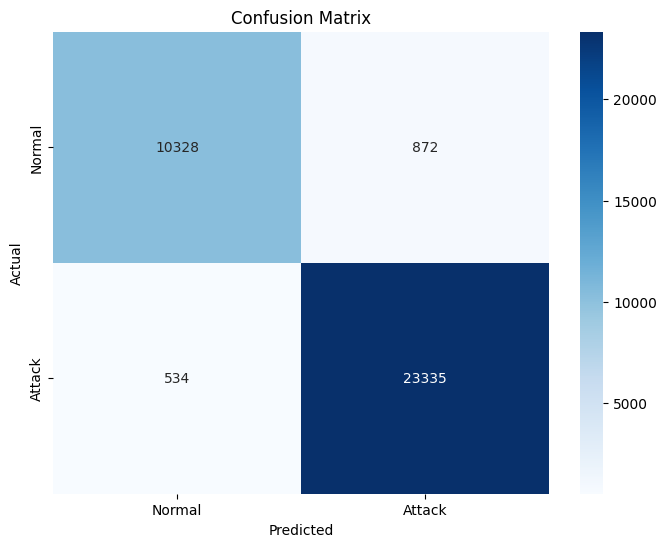


Accuracy of loaded model: 0.9599076107103139


In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pickle
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Load and Understand the Dataset
# Loading the CSV file
df = pd.read_csv('UNSW_NB15_testing-set.csv')

# Display first 5 rows
print("First 5 rows of the dataset:")
print(df.head())

# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())

# Statistical summary
print("\nStatistical summary of numerical columns:")
print(df.describe())

# Step 2: Data Preprocessing
# Drop the 'id' column as it's not useful for prediction
df = df.drop(['id'], axis=1)

# Handle missing values
# For categorical columns, fill missing values with mode
categorical_columns = ['proto', 'service', 'state', 'attack_cat']
for col in categorical_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# For numerical columns, fill missing values with median
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_columns:
    df[col] = df[col].fillna(df[col].median())

# Encode categorical columns
label_encoders = {}
for col in categorical_columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le  # Save encoders for potential future use

# Separate features and target
X = df.drop(['label', 'attack_cat'], axis=1)  # Features
y = df['label']  # Target (binary classification: 0 or 1)

# Scale numerical features
scaler = StandardScaler()
X = scaler.fit_transform(X)

# Split the dataset into train and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Step 3: Model Selection and Training
# Initialize the Random Forest Classifier
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Step 4: Model Evaluation
# Make predictions
y_pred = model.predict(X_test)

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# Print metrics
print("\nModel Performance Metrics:")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Step 5: Save the Model
# Save the trained model to a .pkl file
pickle.dump(model, open('model.pkl', 'wb'))

# Load the model back to verify
loaded_model = pickle.load(open('model.pkl', 'rb'))

# Verify the loaded model by making predictions
y_pred_loaded = loaded_model.predict(X_test)
print("\nAccuracy of loaded model:", accuracy_score(y_test, y_pred_loaded))